In [42]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/comment-category-prediction-challenge/Sample.csv
/kaggle/input/competitions/comment-category-prediction-challenge/train.csv
/kaggle/input/competitions/comment-category-prediction-challenge/test.csv


In [43]:
import warnings
warnings.filterwarnings('ignore') 

# **EXPLORATORY DATA ANALYSIS**

# Loading and Inspecting the Data

In [44]:
train_df = pd.read_csv("/kaggle/input/competitions/comment-category-prediction-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/comment-category-prediction-challenge/test.csv")

In [45]:
## viewing the training data
print("Shape of the Training Data:", train_df.shape)
train_df.head()

Shape of the Training Data: (198000, 15)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [46]:
## viewing the test data
print("Shape of the Test Data:", test_df.shape)
test_df.head()

Shape of the Test Data: (102000, 14)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment
0,2024-02-08 13:13:27.998156+00:00,72,2,0,0,4,1,0,10,NaN,NaN,NaN,False,Canada is being run by someone with the mental...
1,2024-03-01 23:33:25.547123+00:00,123,0,0,0,0,0,0,10,NaN,NaN,NaN,False,And your comment is left-wing drivel
2,2024-02-09 21:52:48.426303+00:00,120,0,0,0,3,0,0,4,NaN,NaN,NaN,False,http://talkingpointsmemo..com/dc/special-couns...
3,2024-02-17 03:43:02.980294+00:00,123,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"Trump jl Blames: The Secret Service, James Com..."
4,2024-04-24 02:27:57.145155+00:00,123,0,0,0,0,0,0,11,NaN,NaN,NaN,False,It was hard enough to get the stench out of th...


In [47]:
## data types of each column in the training data
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [48]:
## data types of each column in the test data
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  102000 non-null  object
 1   post_id       102000 non-null  int64 
 2   emoticon_1    102000 non-null  int64 
 3   emoticon_2    102000 non-null  int64 
 4   emoticon_3    102000 non-null  int64 
 5   upvote        102000 non-null  int64 
 6   downvote      102000 non-null  int64 
 7   if_1          102000 non-null  int64 
 8   if_2          102000 non-null  int64 
 9   race          26731 non-null   object
 10  religion      26731 non-null   object
 11  gender        26731 non-null   object
 12  disability    102000 non-null  bool  
 13  comment       102000 non-null  object
dtypes: bool(1), int64(8), object(5)
memory usage: 10.2+ MB


In [49]:
## basic statistics of numerical columns in the training data
train_df.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


In [50]:
## basic statistics of numerical columns in the test data
test_df.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2
count,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000
mean,68.359422,0.280078,0.048353,0.118902,2.609402,0.661667,1.903078,7.956206
std,27.923491,1.043353,0.257278,0.480484,4.966033,1.965536,26.273483,15.186746
min,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000
max,129.000000,95.000000,8.000000,19.000000,189.000000,95.000000,1866.000000,1798.000000


Cleaning the Data

Identifying and Handling missing values

In [51]:
## number of missing values per column 
print("The number of missing values per column in the Training Data:", train_df.isna().sum())

The number of missing values per column in the Training Data: created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64


In [52]:
print("The number of missing values per column in the Test Data:", test_df.isna().sum())

The number of missing values per column in the Test Data: created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64


Identifying and Handling Duplicates

In [53]:
## Finding duplicates 
print("Dupilcates in the Training Data:", train_df.duplicated().sum())
print("Dupilcates in the Test Data:", test_df.duplicated().sum())

Dupilcates in the Training Data: 0
Dupilcates in the Test Data: 0


Identifying and Handling Outliers

In [54]:
import seaborn as sns 
import matplotlib.pyplot as plt

In [55]:
# Compute IQR for upvote
Q1 = train_df["upvote"].quantile(0.25)
Q3 = train_df["upvote"].quantile(0.75)

IQR = Q3 - Q1

lower_up = Q1 - 1.5 * IQR
upper_up = Q3 + 1.5 * IQR

# Extract outliers
outliers_up = train_df[(train_df["upvote"] < lower_up) | (train_df["upvote"] > upper_up)]

print("Number of outliers (upvotes):", len(outliers_up))

Number of outliers (upvotes): 17304


In [56]:
# Compute IQR for downvote
Q1 = train_df["downvote"].quantile(0.25)
Q3 = train_df["downvote"].quantile(0.75)

IQR = Q3 - Q1

lower_down = Q1 - 1.5 * IQR
upper_down = Q3 + 1.5 * IQR

# Extract outliers
outliers_down = train_df[(train_df["downvote"] < lower_down) | (train_df["downvote"] > upper_down)]

print("Number of outliers (downvotes):", len(outliers_down))

Number of outliers (downvotes): 15173


In [57]:
outliers = pd.concat([outliers_up, outliers_down]).drop_duplicates()
print("Total number of outliers:", len(outliers))

Total number of outliers: 28282


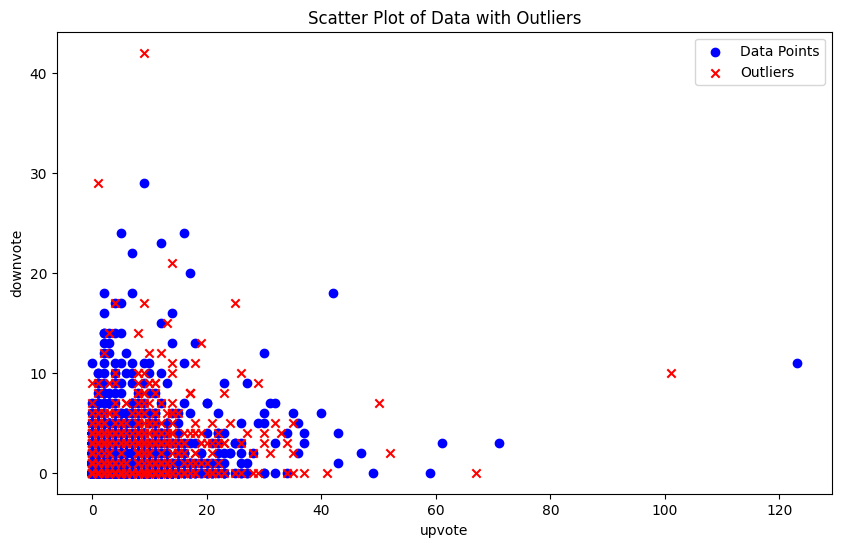

In [58]:
## Scatter Plot 
## visualize data and outliers 
sample = train_df.sample(5000)
plt.figure(figsize=[10,6])
plt.scatter(sample["upvote"], sample["downvote"], c="blue", label = "Data Points")
plt.scatter(outliers.sample(500)["upvote"], outliers.sample(500)["downvote"], c='red', marker='x', label='Outliers')
plt.title('Scatter Plot of Data with Outliers')
plt.xlabel("upvote")
plt.ylabel("downvote")
plt.legend()
plt.show()

##Outliers are detected but retained since they represent genuine high-engagement comments rather than errors.

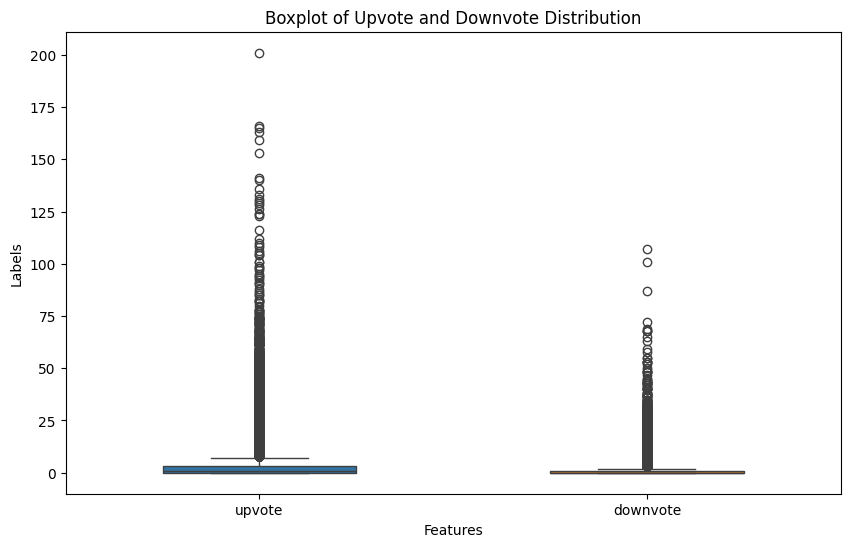

In [59]:
## boxplot 
plt.figure(figsize=[10,6])
sns.boxplot(data=train_df[["upvote", "downvote"]], width=0.5)
plt.title("Boxplot of Upvote and Downvote Distribution")
plt.xlabel("Features")
plt.ylabel("Labels")
plt.show()

## data is heavily right-skewed

The boxplot reveals heavy right-skewness and a median of zero, meaning most comments have no engagement while a few "viral" outliers reach 200+.

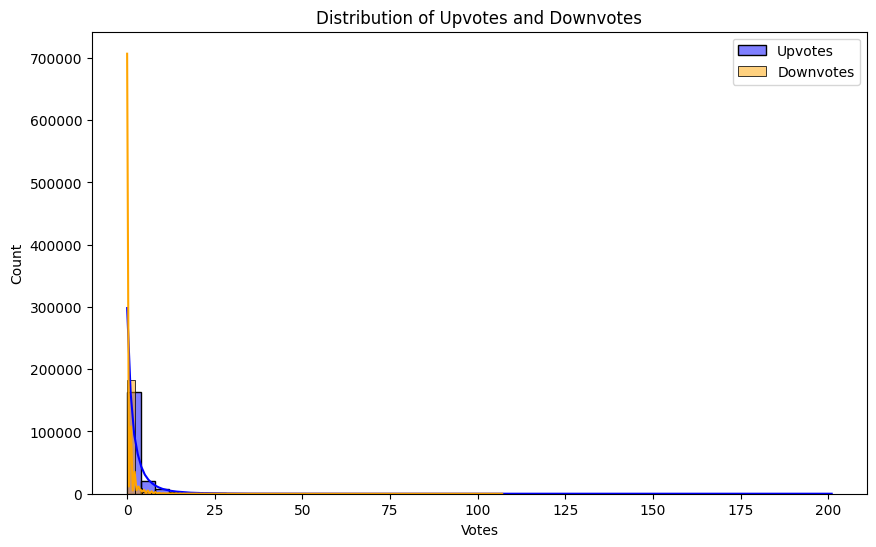

In [60]:
## histogram
plt.figure(figsize=(10,6))

sns.histplot(train_df["upvote"], bins=50, color="blue", label="Upvotes", kde=True)
sns.histplot(train_df["downvote"], bins=50, color="orange", label="Downvotes", kde=True)

plt.xlabel("Votes")
plt.ylabel("Count")
plt.title("Distribution of Upvotes and Downvotes")
plt.legend()

plt.show()

The histogram confirms a long-tailed, power-law distribution, where the vast majority of comments have zero or near-zero engagement. This extreme sparsity indicates that engagement features are highly unbalanced, making it difficult for standard models to learn from the "average" case.

# Univariate Analysis

***Numerical Univariate Analysis***

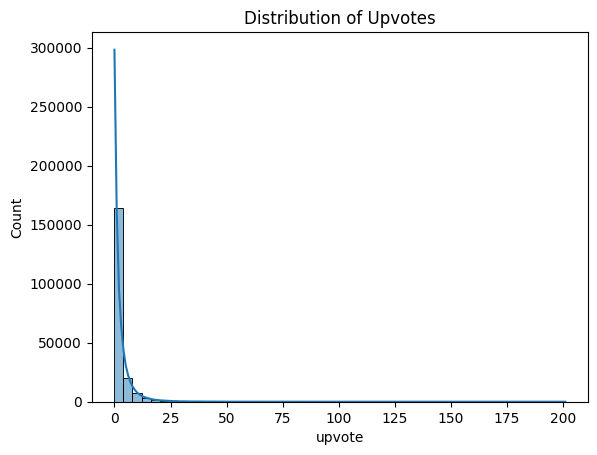

In [61]:
## distribution of upvotes
sns.histplot(train_df["upvote"], bins=50, kde=True)
plt.title("Distribution of Upvotes")
plt.show()

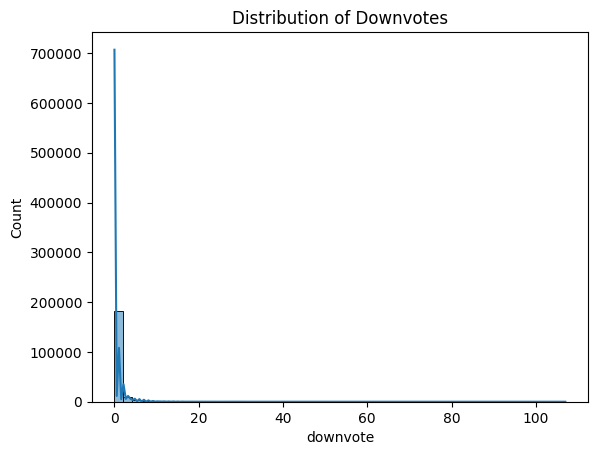

In [62]:
## distribution of downvotes
sns.histplot(train_df["downvote"], bins=50, kde=True)
plt.title("Distribution of Downvotes")
plt.show()

These histograms display a L-shaped (or Power Law) distribution, where a massive spike at zero indicates that most comments receive no engagement. This "zero-inflation" makes the data highly skewed, meaning traditional Mean-based models would struggle to find a representative center.

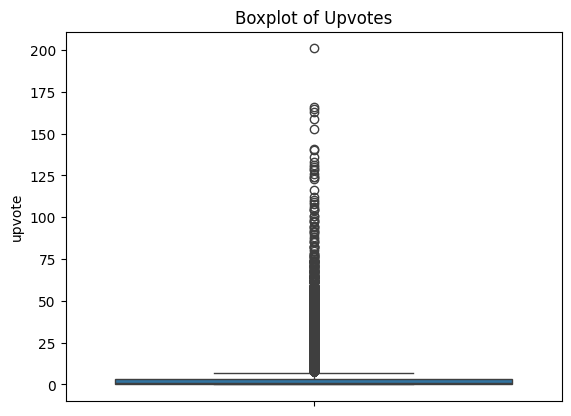

In [63]:
## boxplot of upvotes 
sns.boxplot(y=train_df["upvote"])
plt.title("Boxplot of Upvotes")
plt.show()

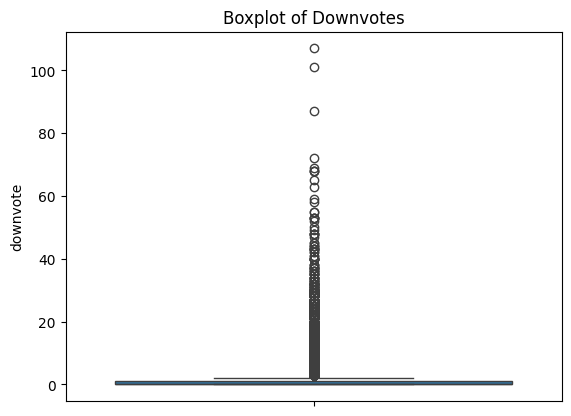

In [64]:
## boxplot of downvotes
sns.boxplot(y=train_df["downvote"])
plt.title("Boxplot of Downvotes")
plt.show()

***Categorical Univariate Analysis***

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64


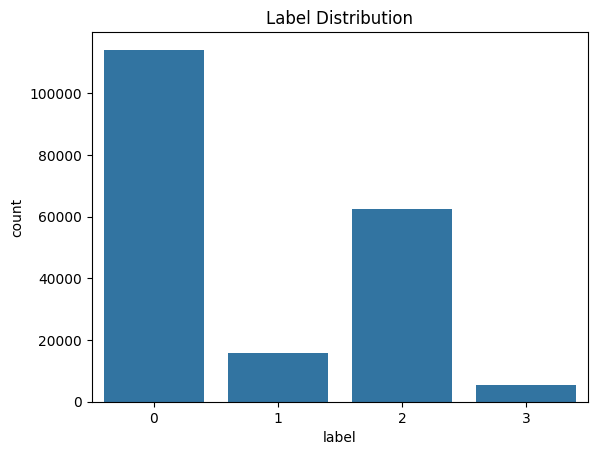

In [65]:
print(train_df["label"].value_counts())
sns.countplot(x=train_df["label"])
plt.title("Label Distribution")
plt.show()

gender
none           36161
female          8037
male            7549
transgender      622
other            208
Name: count, dtype: int64


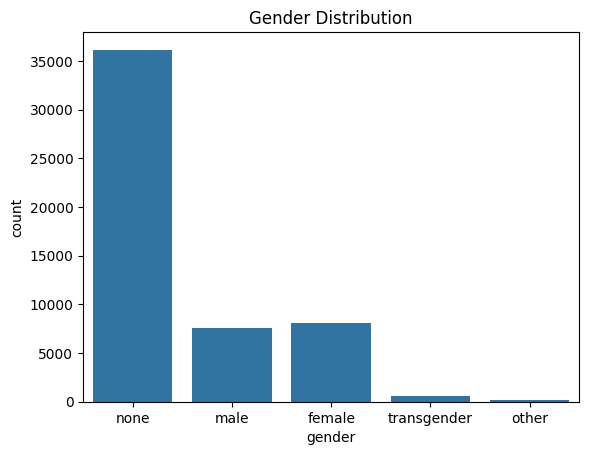

In [66]:
print(train_df["gender"].value_counts())
sns.countplot(x=train_df["gender"])
plt.title("Gender Distribution")
plt.show()

race
none      39682
white      5486
black      3869
other      1654
asian      1263
latino      623
Name: count, dtype: int64


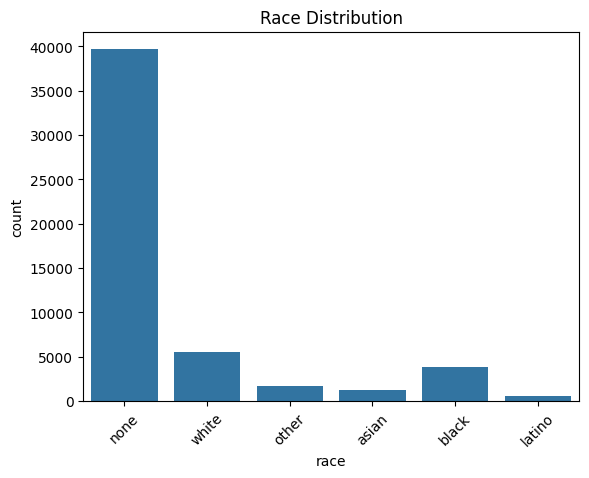

In [67]:
print(train_df["race"].value_counts())
sns.countplot(x=train_df["race"])
plt.title("Race Distribution")
plt.xticks(rotation=45)
plt.show()

religion
none         38249
christian     7191
muslim        4930
jewish        1244
other          547
atheist        219
buddhist       100
hindu           97
Name: count, dtype: int64


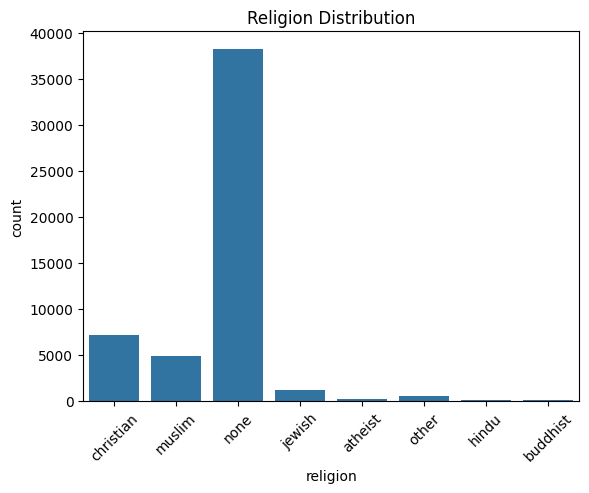

In [68]:
print(train_df["religion"].value_counts())
sns.countplot(x=train_df["religion"])
plt.title("Religion Distribution")
plt.xticks(rotation=45)
plt.show()

The countplots reveal significant class imbalance in both target labels and demographic attributes, with "Label 0" and "None" dominating their respective categories. This imbalance can bias the model toward majority classes, leading to high overall accuracy but poor recall for minority categories like "Transgender" or "Other."

disability
False    195257
True       2743
Name: count, dtype: int64


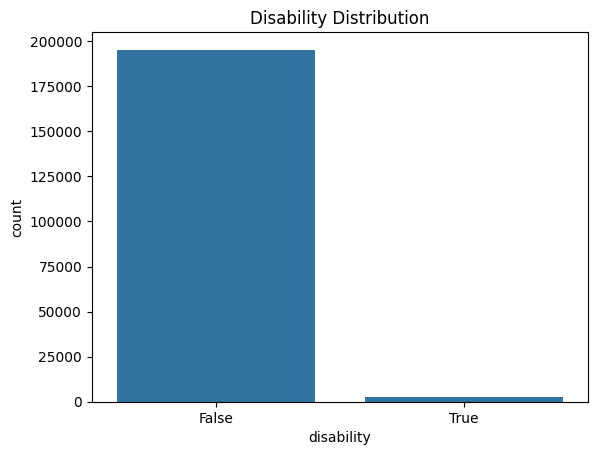

In [69]:
print(train_df["disability"].value_counts())
sns.countplot(x=train_df["disability"])
plt.title("Disability Distribution")
plt.show()

In [70]:
train_df["comment"].isnull().sum()

np.int64(1)

# Bivariate Analysis

***Numerical vs Numerical***

<Axes: xlabel='upvote', ylabel='downvote'>

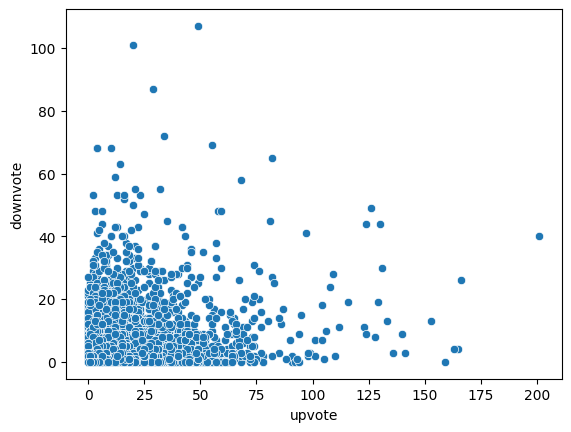

In [71]:
## scatter plot 
sns.scatterplot(data=train_df, x= "upvote", y="downvote")

<Axes: >

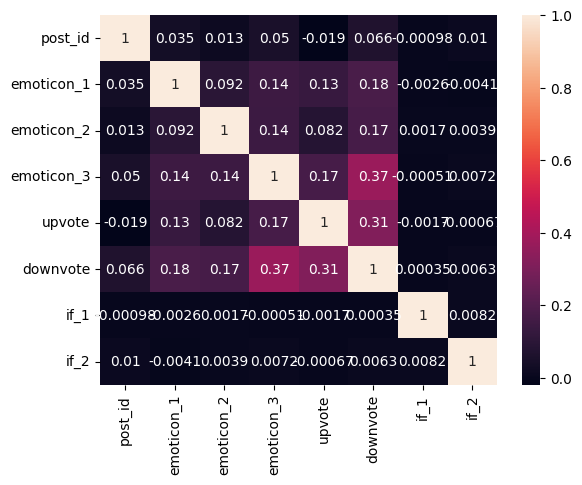

In [72]:
## heatmap 
numerical_features = train_df.select_dtypes(include=np.number).drop(columns=["label"]).columns.tolist()
train_numerical = train_df[numerical_features]
sns.heatmap(train_numerical.corr(), annot=True)

The scatter plot and heatmap show low linear correlation across most features, with upvotes and downvotes only moderately correlated at 0.31. This suggests that engagement metrics provide distinct, non-redundant information, confirming that we shouldn't drop either feature. Furthermore, the overall low correlation scores indicate that the relationship between these numerical features and the labels is likely non-linear, suggesting the use of a complex model like SVC with an RBF kernel.

***Numerical vs Categorical***

<Axes: xlabel='label', ylabel='upvote'>

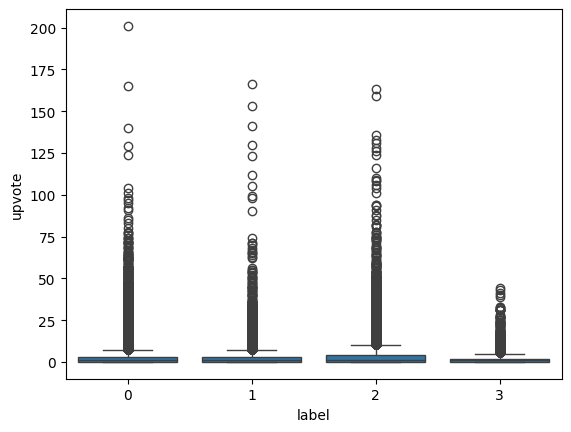

In [73]:
## boxplot: upvote vs label 
sns.boxplot(x="label", y="upvote", data=train_df)

<Axes: xlabel='label', ylabel='downvote'>

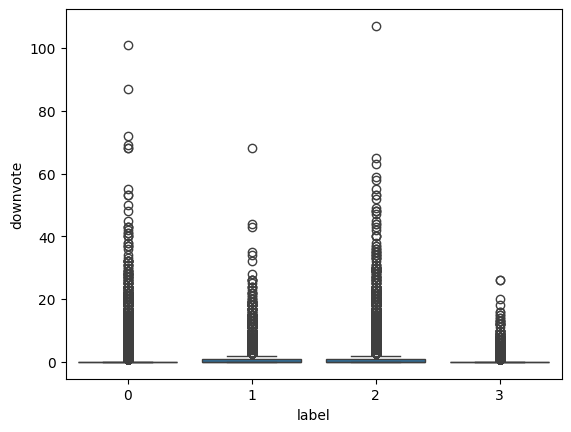

In [74]:
## boxplot: upvote vs label 
sns.boxplot(x="label", y="downvote", data=train_df)

The bivariate boxplots show that while all categories are dominated by low engagement, Label 0 and Label 2 exhibit the highest density of extreme outliers in both upvotes and downvotes.

<Axes: xlabel='label', ylabel='upvote'>

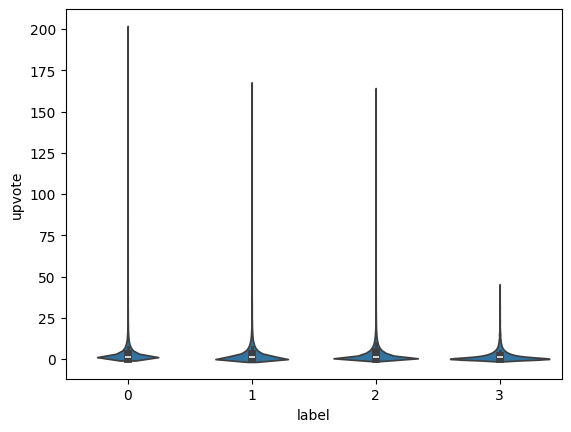

In [76]:
## violinplot
sns.violinplot(train_df, x="label", y = "upvote")

<Axes: xlabel='label', ylabel='downvote'>

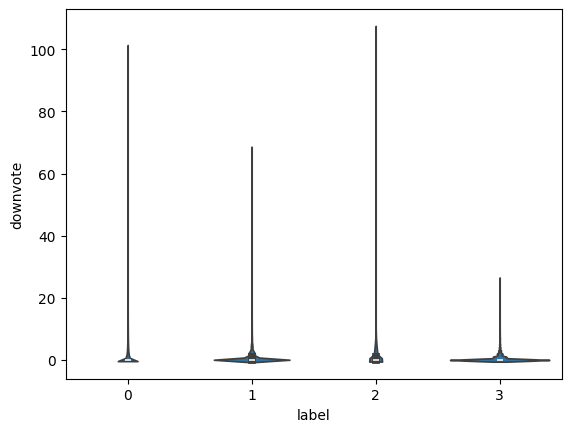

In [77]:
## violinplot
sns.violinplot(train_df, x="label", y = "downvote")

The violin plots illustrate that the probability density for upvotes and downvotes is heavily concentrated at zero for all four labels, confirming the "zero-inflated" nature of the engagement data.

***Categorical vs Categorical***

<Axes: xlabel='label', ylabel='count'>

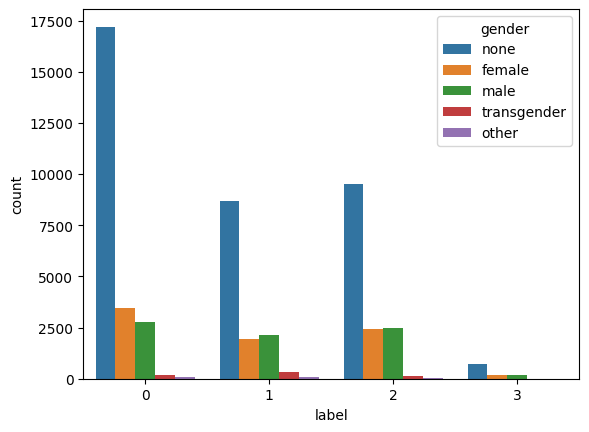

In [78]:
## stacked bar chart 
sns.countplot(data=train_df, x="label", hue="gender")

<Axes: xlabel='label', ylabel='count'>

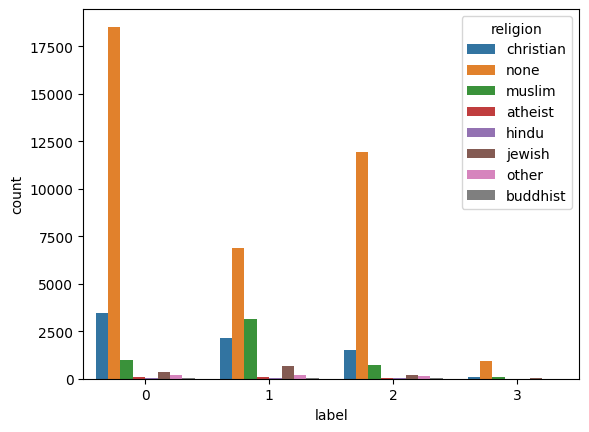

In [79]:
sns.countplot(data=train_df, x="label", hue="religion")

The grouped countplots reveal that demographic attributes like gender and religion are disproportionately represented across the comment labels, with "None" or "Not Disclosed" being the majority for every category. The presence of specific groups, such as "Male/Female" or "Christian/Muslim," varies significantly between Label 0 and Label 2, indicating potential demographic bias within the dataset.

<Axes: xlabel='label', ylabel='count'>

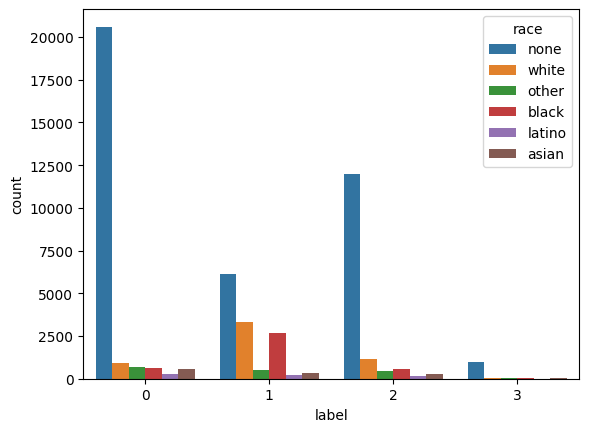

In [80]:
sns.countplot(data=train_df, x="label", hue="race")

<Axes: xlabel='label', ylabel='count'>

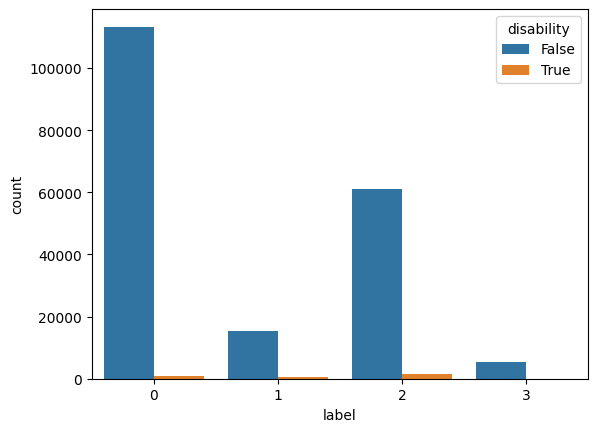

In [81]:
sns.countplot(data=train_df, x="label", hue="disability")

These countplots highlight a severe sparsity in sensitive attributes, where "None" for race and "False" for disability constitute nearly the entire dataset across all labels. While Labels 0, 1, and 2 show varied presence of minority groups, the counts are so low that any model could easily ignore these patterns or, conversely, overfit to them.

# Multivariate Analysis

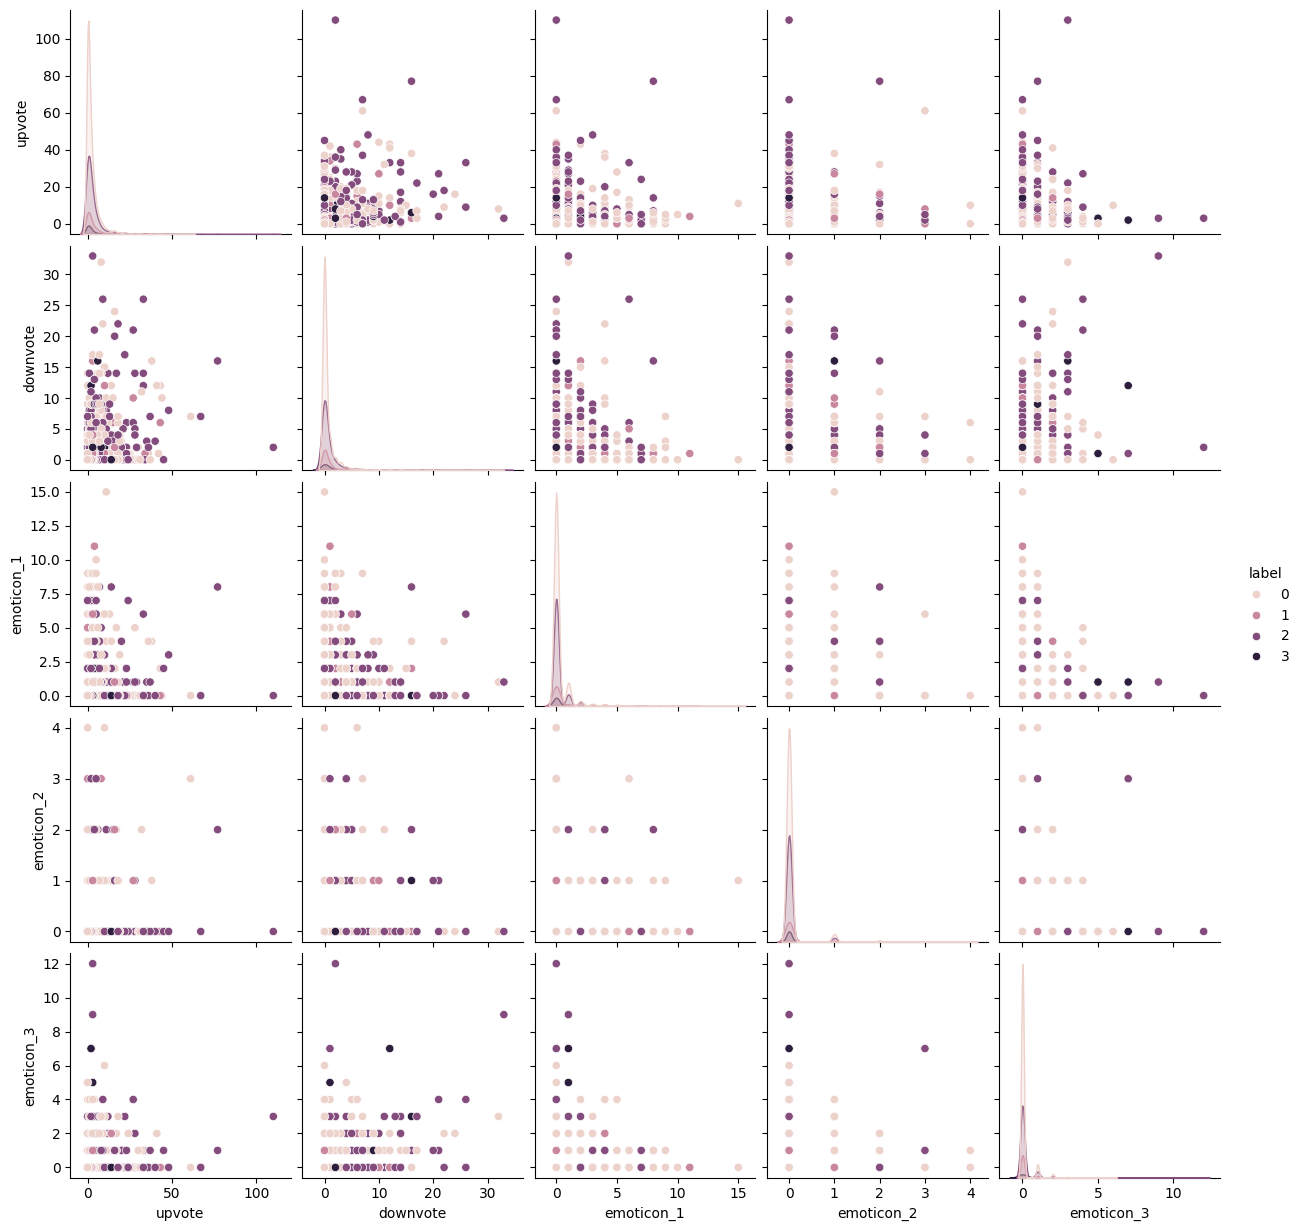

In [82]:
sample = train_df.sample(5000)
sns.pairplot(
    sample[["upvote","downvote","emoticon_1","emoticon_2","emoticon_3", "label"]],
    hue="label",
    diag_kind="kde"
)
plt.show()

The pairplot indicates that numerical features (upvotes, downvotes, and emoticons) are weakly correlated and do not form distinct, linearly separable clusters for the four labels. While there is considerable overlap near the origin, the scatter plots show that "Label 0" and "Label 2" spread further along the axes, suggesting higher engagement variance for those classes.

<Axes: xlabel='upvote', ylabel='downvote'>

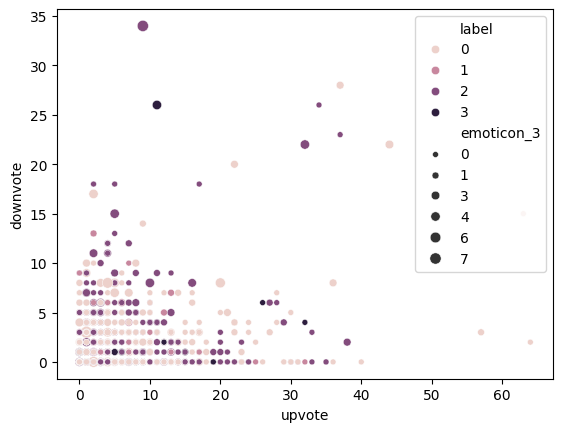

In [83]:
##scatter plot 
sns.scatterplot(data=train_df.sample(5000), x="upvote", y="downvote", hue="label", size="emoticon_3")

he scatter plot demonstrates that while upvotes and downvotes are generally correlated, they do not provide clear linear separation for the classes, as points from all labels overlap significantly near the origin. The variation in point size (emoticon_3) suggests that engagement intensity alone doesn't define a category, though "Label 2" tends to occupy the extreme ends of the engagement spectrum.

# **PREPROCESSING**

# Text Cleaning

In [84]:
import re

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [85]:
train_df["comment"] = train_df["comment"].fillna("")
train_df["comment"] = train_df["comment"].apply(clean_text)

In [86]:
test_df["comment"] = test_df["comment"].fillna("")
test_df["comment"] = test_df["comment"].apply(clean_text)

# Handling Missing Values

In [87]:
print("Missing values per column:")
print(train_df.isna().sum())
print("Missing % values per column:")
print((train_df.isna().sum()/len(train_df))*100)

Missing values per column:
created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              0
label                0
dtype: int64
Missing % values per column:
created_date     0.00000
post_id          0.00000
emoticon_1       0.00000
emoticon_2       0.00000
emoticon_3       0.00000
upvote           0.00000
downvote         0.00000
if_1             0.00000
if_2             0.00000
race            73.44596
religion        73.44596
gender          73.44596
disability       0.00000
comment          0.00000
label            0.00000
dtype: float64


In [88]:
print("Missing values per column:")
print(test_df.isna().sum())
print("Missing % values per column:")
print((test_df.isna().sum()/len(test_df))*100)

Missing values per column:
created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64
Missing % values per column:
created_date     0.000000
post_id          0.000000
emoticon_1       0.000000
emoticon_2       0.000000
emoticon_3       0.000000
upvote           0.000000
downvote         0.000000
if_1             0.000000
if_2             0.000000
race            73.793137
religion        73.793137
gender          73.793137
disability       0.000000
comment          0.000000
dtype: float64


About 74% of the data is missing in the features *race, religion, and gender*. Since the missing data is significantly large, these columns must be dropped

In [89]:
train_df = train_df.drop(columns = ["race", "religion", "gender", "post_id"])
train_df.head()

,created_date,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,0,0,0,0,1,0,10,False,she might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,0,0,0,6,0,0,4,False,under alaska law a nontribal member is not bou...,0
2,2024-04-24 20:32:17.014931+00:00,0,1,1,0,0,0,10,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,0,0,0,5,0,0,10,False,ps that should have been rot instead of corrup...,2
4,2023-09-09 23:12:05.689498+00:00,0,0,0,0,0,0,10,False,today the confederate flagtomorrow the nazi fl...,2


In [90]:
test_df = test_df.drop(columns = ["race", "religion", "gender", "post_id"])
test_df.head()

,created_date,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,disability,comment
0,2024-02-08 13:13:27.998156+00:00,2,0,0,4,1,0,10,False,canada is being run by someone with the mental...
1,2024-03-01 23:33:25.547123+00:00,0,0,0,0,0,0,10,False,and your comment is leftwing drivel
2,2024-02-09 21:52:48.426303+00:00,0,0,0,3,0,0,4,False,
3,2024-02-17 03:43:02.980294+00:00,0,0,0,0,0,0,4,False,trump jl blames the secret service james comey...
4,2024-04-24 02:27:57.145155+00:00,0,0,0,0,0,0,11,False,it was hard enough to get the stench out of th...


# Handling Categorical - Features Encoding

In [91]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_df["disability"] = le.fit_transform(train_df["disability"])
test_df["disability"] = le.transform(test_df["disability"])

The "Disability" feature was transformed using Label Encoding to convert binary text strings (True/False) into a machine-readable numerical format (1/0).

In [92]:
train_df.head()

,created_date,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,0,0,0,0,1,0,10,0,she might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,0,0,0,6,0,0,4,0,under alaska law a nontribal member is not bou...,0
2,2024-04-24 20:32:17.014931+00:00,0,1,1,0,0,0,10,0,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,0,0,0,5,0,0,10,0,ps that should have been rot instead of corrup...,2
4,2023-09-09 23:12:05.689498+00:00,0,0,0,0,0,0,10,0,today the confederate flagtomorrow the nazi fl...,2


# **FEATURE ENGINEERING**

# Feature Creation

In [93]:
## creating a vote ratio of upvote:downvote
train_df['vote_ratio'] = train_df['upvote'] / (train_df['upvote'] + train_df['downvote'] + 1)
test_df['vote_ratio'] = test_df['upvote'] / (test_df['upvote'] + test_df['downvote'] + 1)

train_df["total_votes"] = train_df["upvote"] + train_df["downvote"]
train_df["vote_diff"] = train_df["upvote"] - train_df["downvote"]

test_df["total_votes"] = test_df["upvote"] + test_df["downvote"]
test_df["vote_diff"] = test_df["upvote"] - test_df["downvote"]

In [94]:
train_df["created_date"] = pd.to_datetime(train_df["created_date"], errors="coerce")
test_df["created_date"] = pd.to_datetime(test_df["created_date"], errors="coerce")

for df in [train_df, test_df]:
    df["year"] = df["created_date"].dt.year
    df["month"] = df["created_date"].dt.month
    df["day"] = df["created_date"].dt.day
    df["dayofweek"] = df["created_date"].dt.dayofweek
    df["hour"] = df["created_date"].dt.hour
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

train_df = train_df.drop(columns=["created_date"])
test_df = test_df.drop(columns=["created_date"])

Defining the columns:

In [ ]:
num_cols =['upvote', 'downvote', 'vote_ratio', 'total_votes', 'vote_diff', 'year', 'month', 'day', 'dayofweek','hour', 'is_weekend']
hc_cat_cols = ['emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2']
binary_cat_cols = ['disability']
text_col = 'comment'

In [96]:
# Force high-cardinality and binary columns to string type
cols_to_convert = hc_cat_cols + binary_cat_cols
train_df[cols_to_convert] = train_df[cols_to_convert].astype(str)
test_df[cols_to_convert] = test_df[cols_to_convert].astype(str)

In [97]:
train_df[text_col] = train_df[text_col].fillna("")
test_df[text_col] = test_df[text_col].fillna("")

# Feature Scaling

In [98]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import RobustScaler
import category_encoders as ce
from sklearn.pipeline import Pipeline, FeatureUnion

In [99]:
num_pipeline = Pipeline([
    ("robust_scaler", RobustScaler())
])

To handle the heavy right-skewness and extreme outliers identified during EDA, a RobustScaler pipeline is implemented. Unlike standard scaling, this uses the Median and Interquartile Range (IQR) for normalization, ensuring that "viral" engagement counts do not skew the feature values or suppress the signals from the majority of the data.

In [100]:
cat_pipeline = Pipeline([
    ('target_encoder', ce.TargetEncoder(smoothing=10, 
    min_samples_leaf=20))
])

For high-cardinality categorical features like emoticons and identity flags, Target Encoding is utilized. This replaces category labels with the mean of the target variable for each group, capturing the statistical relationship between these features and the output classes without drastically increasing the dimensionality of the dataset.

In [101]:
text_pipeline = Pipeline([
    ('text', FeatureUnion([
        ('word_tfidf', TfidfVectorizer(
            max_features=20000,
            ngram_range=(1, 3),
            min_df=3,
            max_df=0.95,
            sublinear_tf=True,
            analyzer='word'
        )),
        ('char_tfidf', TfidfVectorizer(
            max_features=20000,
            ngram_range=(3, 5),
            analyzer='char_wb',
            sublinear_tf=True
        ))
    ]))
])

# Feature Extraction

In [102]:
preprocessor = ColumnTransformer(
    transformers = [
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, hc_cat_cols + binary_cat_cols),
        ("text", text_pipeline, text_col)
    ]
)

In [103]:
print(train_df['label'].value_counts(normalize=True))

label
0    0.576631
2    0.315354
1    0.080394
3    0.027621
Name: proportion, dtype: float64


# SPLITTING THE DATASET

In [104]:
from sklearn.model_selection import train_test_split

X = train_df.drop(columns = ["label"])
y = train_df["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y #to address the class imbalance
)

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(y_val)}")

Training set size: 158400
Validation set size: 39600


# **MODEL BUILDING**

# Logistic Regression

In [105]:
from sklearn.linear_model import LogisticRegression
log_reg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        multi_class='multinomial', #handle the four distinct comment labels simultaneously
        solver='lbfgs', #efficiency in handling multinomial loss functions and its ability to converge reliably within the specified
        max_iter=1000, 
        class_weight='balanced', #adjusts the importance of each sample inversely proportional to its class frequency in the training data
        C=0.1  #to prevent overfitting
    ))
])

In [106]:
log_reg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('robust_scaler',
                                                                   RobustScaler())]),
                                                  ['upvote', 'downvote',
                                                   'vote_ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('target_encoder',
                                                                   TargetEncoder())]),
                                                  ['emoticon_1', 'emoticon_2',
                                                   'emoticon_3', 'if_1', 'if_2',
                                                   'disability']),
                                                 ('text',
                                                  Pipeline(steps=[('text',
                                                                   FeatureUnion(transformer_list=[('word_tfidf',
                                                                                                   TfidfVectorizer(max_df=0.95,
                                                                                                                   max_features=20000,
                                                                                                                   min_df=3,
                                                                                                                   ngram_range=(1,
                                                                                                                                3),
                                                                                                                   sublinear_tf=True)),
                                                                                                  ('char_tfidf',
                                                                                                   TfidfVectorizer(analyzer='char_wb',
                                                                                                                   max_features=20000,
                                                                                                                   ngram_range=(3,
                                                                                                                                5),
                                                                                                                   sublinear_tf=True))]))]),
                                                  'comment')])),
                ('classifier',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=1000,
                                    multi_class='multinomial'))])

In [107]:
y_pred_lr = log_reg_pipeline.predict(X_val)

In [108]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_val, y_pred_lr))

Accuracy: 0.8975252525252525


In [109]:
print(classification_report(y_val, y_pred_lr))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96     22835
           1       0.69      0.86      0.77      3183
           2       0.90      0.82      0.86     12488
           3       0.46      0.83      0.60      1094

    accuracy                           0.90     39600
   macro avg       0.76      0.86      0.79     39600
weighted avg       0.91      0.90      0.90     39600



In [110]:
print("\nConfusion Matrix")
cm=confusion_matrix(y_val, y_pred_lr)
# Class labels
labels = ['0', '1', '2', '3']

# Convert to DataFrame for better readability
cm_df = pd.DataFrame(cm,
                     index=[f'Actual_{label}' for label in labels],
                     columns=[f'Predicted_{label}' for label in labels])

print("Confusion Matrix with Labels")
print(cm_df)


Confusion Matrix
Confusion Matrix with Labels
          Predicted_0  Predicted_1  Predicted_2  Predicted_3
Actual_0        21692          239          668          236
Actual_1           38         2729          307          109
Actual_2          650          920        10213          705
Actual_3           24           60          102          908


## Logistic Regression Insights

### Overall Performance
The model achieves 90% accuracy, with a strong weighted F1-score (0.90). However, the macro F1-score (~0.79) reveals imbalance in performance across classes, with better results on majority classes (0 and 2) compared to minority classes (1 and 3).

### Class-wise Behavior
- **Class 0**: Very stable with high precision and recall (~0.96)  
- **Class 2**: Strong performance with balanced precision and recall  
- **Class 1**: Good recall but lower precision → some false positives  
- **Class 3**: High recall (0.83) but low precision (0.46), indicating over-prediction  

### Key Observations
- The model tends to **over-predict minority classes**, especially Class 3  
- Confusion is most prominent between **Class 1 and Class 2**, suggesting overlapping features  
- Using `class_weight='balanced'` improves recall for minority classes but introduces precision trade-offs  

### Takeaway
Logistic Regression provides a strong baseline but struggles with separating overlapping classes. This highlights the need for more expressive models or ensemble approaches to better capture complex patterns.

# SVC

In [111]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

base_svc = LinearSVC(max_iter = 2000, C = 0.5, class_weight='balanced', random_state=42)

calibrated_svc = CalibratedClassifierCV(base_svc, method='sigmoid', cv=3)

svc_pipeline = Pipeline([('pre', preprocessor), ('clf', calibrated_svc)])

In [112]:
svc_pipeline.fit(X_train, y_train)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('robust_scaler',
                                                                   RobustScaler())]),
                                                  ['upvote', 'downvote',
                                                   'vote_ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('target_encoder',
                                                                   TargetEncoder())]),
                                                  ['emoticon_1', 'emoticon_2',
                                                   'emoticon_3', 'if_1', 'if_2',
                                                   'disability']),
                                                 ('text',
                                                  Pipeline(steps=[('text',
                                                                   FeatureUnion(transformer_list=[('word_tfidf',
                                                                                                   TfidfVectorizer(max_df=0.95,
                                                                                                                   max_features=20000,
                                                                                                                   min_df=3,
                                                                                                                   ngram_range=(1,
                                                                                                                                3),
                                                                                                                   sublinear_tf=True)),
                                                                                                  ('char_tfidf',
                                                                                                   TfidfVectorizer(analyzer='char_wb',
                                                                                                                   max_features=20000,
                                                                                                                   ngram_range=(3,
                                                                                                                                5),
                                                                                                                   sublinear_tf=True))]))]),
                                                  'comment')])),
                ('clf',
                 CalibratedClassifierCV(cv=3,
                                        estimator=LinearSVC(C=0.5,
                                                            class_weight='balanced',
                                                            max_iter=2000,
                                                            random_state=42)))])

In [113]:
y_pred_svc = svc_pipeline.predict(X_val)

In [114]:
print("Accuracy:", accuracy_score(y_val, y_pred_svc))

Accuracy: 0.9145707070707071


In [115]:
print(classification_report(y_val, y_pred_svc))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96     22835
           1       0.78      0.76      0.77      3183
           2       0.86      0.92      0.89     12488
           3       0.77      0.54      0.63      1094

    accuracy                           0.91     39600
   macro avg       0.84      0.79      0.81     39600
weighted avg       0.91      0.91      0.91     39600



In [116]:
print("\nConfusion Matrix")
cm=confusion_matrix(y_val, y_pred_svc)
# Class labels
labels = ['0', '1', '2', '3']

# Convert to DataFrame for better readability
cm_df = pd.DataFrame(cm,
                     index=[f'Actual_{label}' for label in labels],
                     columns=[f'Predicted_{label}' for label in labels])

print("Confusion Matrix with Labels")
print(cm_df)


Confusion Matrix
Confusion Matrix with Labels
          Predicted_0  Predicted_1  Predicted_2  Predicted_3
Actual_0        21740          160          880           55
Actual_1           78         2427          639           39
Actual_2          503          435        11464           86
Actual_3           64           72          372          586


## Linear SVC Insights

### Overall Performance
Linear SVC improves performance over Logistic Regression, achieving 91% accuracy and a higher macro F1-score (0.81). This indicates better separation of overlapping text patterns.

### Class-wise Behavior
- **Class 0**: Very strong and stable (high precision & recall)  
- **Class 2**: Strong recall (0.92), good overall performance  
- **Class 1**: Balanced precision and recall (0.77)  
- **Class 3**: Improved precision (0.77) but lower recall (0.54)  

### Key Observations
- SVC is more **conservative**, reducing false positives compared to Logistic Regression  
- Significant improvement in **precision for minority classes (1 & 3)**  
- Trade-off: **recall drops for Class 3**, meaning some instances are missed  

### Takeaway
Linear SVC offers better precision and stability, especially for minority classes, but struggles to capture all complex patterns. This motivates using ensemble methods or non-linear models to improve recall.

 **CROSS VALIDATION**

In [117]:
#from sklearn.model_selection import cross_val_score

#scores = cross_val_score(
    #log_reg_pipeline,
    #X,
    #y,
    #cv=5,
    #scoring="accuracy"
#)

#print("Fold Accuracies:", scores)
#print("Mean Accuracy:", scores.mean())

In [118]:
#from sklearn.model_selection import cross_val_score

#scores = cross_val_score(
   # svc_pipeline,
   # X,
   # y,
   # cv=5,
   # scoring="accuracy"
#)

#print("Fold Accuracies:", scores)
#print("Mean Accuracy:", scores.mean())

In [119]:
#from sklearn.model_selection import GridSearchCV

#param_grid = {
#    'clf__estimator__C': [0.5],  
#   'clf__estimator__max_iter': [2000]
#}

#grid = GridSearchCV(
    #svc_pipeline,
    #param_grid,
    #cv=5,
    #scoring="accuracy",
    #n_jobs=-1
#)

#grid.fit(X_train, y_train)

#print("Best Parameters:", grid.best_params_)
#print("Best CV Score:", grid.best_score_)

In [120]:
#best_svc = grid.best_estimator_

#y_pred = best_svc.predict(X_val)

In [121]:
#print("Accuracy:", accuracy_score(y_val, y_pred))

#print("\nConfusion Matrix")
#cm=confusion_matrix(y_val, y_pred)
# Class labels
#labels = ['0', '1', '2', '3']

# Convert to DataFrame for better readability
#cm_df = pd.DataFrame(cm,
 #                    index=[f'Actual_{label}' for label in labels],
 #                    columns=[f'Predicted_{label}' for label in labels])

#print("Confusion Matrix with Labels")
#print(cm_df)

#print("\nClassification Report")
#print(classification_report(y_val, y_pred))

# **Random Forest (Bagging)**

In [122]:
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.pipeline import Pipeline
#from sklearn.ensemble import RandomForestClassifier

#rf_pipeline = Pipeline([
#    ("preprocessor", preprocessor),
#    ("RandomForest", RandomForestClassifier(
 #       n_estimators=150,
  #      n_jobs = -1,
   #     class_weight = 'balanced',
   #     random_state=42,
   #     verbose = 1
   # ))
#])

In [123]:
#rf_pipeline.fit(X_train, y_train)

In [124]:
#y_pred_rf = rf_pipeline.predict(X_val)

In [125]:
#print("Accuracy:", accuracy_score(y_val, y_pred_rf))

#cm = confusion_matrix(y_val, y_pred_rf)

#print("Confusion Matrix")
#print(cm)

#print("\nClassification Report")
#print(classification_report(y_val, y_pred_rf))

# **Light GBM (Boosting)**

In [126]:
from lightgbm import LGBMClassifier

lgbm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("LGBM", LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=20,
    feature_fraction=0.1,   
    reg_alpha=0.1,          
    class_weight='balanced',
    n_jobs=2,
    random_state = 42
)
    )
])

In [127]:
lgbm_pipeline.fit(X_train, y_train)

[LightGBM] [Warning] feature_fraction is set=0.1, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.1
[LightGBM] [Warning] feature_fraction is set=0.1, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.1
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 78.128924 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5929226
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 40009
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('robust_scaler',
                                                                   RobustScaler())]),
                                                  ['upvote', 'downvote',
                                                   'vote_ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('target_encoder',
                                                                   TargetEncoder())]),
                                                  ['emoticon_1', 'emoticon_2',
                                                   'emoticon_3', 'if_1', 'if_2',
                                                   'disability']),
                                                 ('text',
                                                  Pipeline(steps=[('text',
                                                                   FeatureUnion(transformer_list=[...tfidf',
                                                                                                   TfidfVectorizer(max_df=0.95,
                                                                                                                   max_features=20000,
                                                                                                                   min_df=3,
                                                                                                                   ngram_range=(1,
                                                                                                                                3),
                                                                                                                   sublinear_tf=True)),
                                                                                                  ('char_tfidf',
                                                                                                   TfidfVectorizer(analyzer='char_wb',
                                                                                                                   max_features=20000,
                                                                                                                   ngram_range=(3,
                                                                                                                                5),
                                                                                                                   sublinear_tf=True))]))]),
                                                  'comment')])),
                ('LGBM',
                 LGBMClassifier(class_weight='balanced', feature_fraction=0.1,
                                n_jobs=2, num_leaves=20, random_state=42,
                                reg_alpha=0.1))])

In [128]:
y_pred_lgbm = lgbm_pipeline.predict(X_val)

[LightGBM] [Warning] feature_fraction is set=0.1, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.1


In [129]:
print("Accuracy:", accuracy_score(y_val, y_pred_lgbm))

print("\nConfusion Matrix")
cm=confusion_matrix(y_val, y_pred_lgbm)
# Class labels
labels = ['0', '1', '2', '3']

# Convert to DataFrame for better readability
cm_df = pd.DataFrame(cm,
                     index=[f'Actual_{label}' for label in labels],
                     columns=[f'Predicted_{label}' for label in labels])

print("Confusion Matrix with Labels")
print(cm_df)

print("\nClassification Report")
print(classification_report(y_val, y_pred_lgbm))

Accuracy: 0.8821969696969697

Confusion Matrix
Confusion Matrix with Labels
          Predicted_0  Predicted_1  Predicted_2  Predicted_3
Actual_0        20931          518          941          445
Actual_1           18         2813          243          109
Actual_2          348          934        10283          923
Actual_3           18           65          103          908

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.92      0.95     22835
           1       0.65      0.88      0.75      3183
           2       0.89      0.82      0.85     12488
           3       0.38      0.83      0.52      1094

    accuracy                           0.88     39600
   macro avg       0.73      0.86      0.77     39600
weighted avg       0.91      0.88      0.89     39600



## LightGBM Insights

### Overall Performance
LightGBM achieves ~88% accuracy with a strong weighted F1-score (~0.89), demonstrating its ability to handle high-dimensional TF-IDF features and capture non-linear patterns.

### Class-wise Behavior
- **Class 0**: Excellent performance (high precision ~0.98, recall ~0.92)  
- **Class 2**: Strong and stable performance  
- **Class 1**: High recall (~0.88), good minority class detection  
- **Class 3**: Very high recall (~0.83) but low precision (~0.38)  

### Key Observations
- LightGBM is highly effective at **capturing minority classes**, especially Class 1 and 3  
- However, it tends to **over-predict Class 3**, leading to many false positives  
- Significant confusion between **Class 2 and Class 3**, indicating overlapping feature patterns  

### Trade-off
- Boosting improves **recall**, especially for difficult classes  
- But comes at the cost of **precision**, particularly for the smallest class  

### Takeaway
LightGBM excels at detecting complex and minority patterns but is more aggressive in its predictions. This makes it a strong candidate for ensemble methods where its high recall can complement more precise models.

In [130]:
from sklearn.model_selection import RandomizedSearchCV

In [131]:
lgbm_param_dist = {
    'LGBM__n_estimators': [100, 200],      # Fewer trees = faster training
    'LGBM__learning_rate': [0.05, 0.1], 
    'LGBM__num_leaves': [20, 31], 
    'LGBM__feature_fraction': [0.1, 0.2],  # Scans only 10-20% of features
    'LGBM__reg_alpha': [0.1, 0.5]
}

lgbm_search = RandomizedSearchCV(
    lgbm_pipeline, 
    param_distributions=lgbm_param_dist, 
    n_iter=4,    
    cv=2,        
    scoring='f1_macro', 
    n_jobs=2,    
    verbose=1,
    random_state=42
)

lgbm_search.fit(X_train, y_train)

print(f"Best LGBM Params: {lgbm_search.best_params_}")

Fitting 2 folds for each of 4 candidates, totalling 8 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

[LightGBM] [Warning] feature_fraction is set=0.1, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.1
[LightGBM] [Warning] feature_fraction is set=0.1, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.1
[LightGBM] [Warning] feature_fraction is set=0.2, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2
[LightGBM] [Warning] feature_fraction is set=0.2, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 81.366813 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4327941
[LightGBM] [Info] Number of data points in the train set: 79200, number of used features: 40008
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1

In [132]:
best_lgbm_model = lgbm_search.best_estimator_

y_lgbm_pred = best_lgbm_model.predict(X_val)

[LightGBM] [Warning] feature_fraction is set=0.1, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.1


In [133]:
print("Accuracy:", accuracy_score(y_val, y_lgbm_pred))

print("\nConfusion Matrix")
cm=confusion_matrix(y_val, y_lgbm_pred)
# Class labels
labels = ['0', '1', '2', '3']

# Convert to DataFrame for better readability
cm_df = pd.DataFrame(cm,
                     index=[f'Actual_{label}' for label in labels],
                     columns=[f'Predicted_{label}' for label in labels])

print("Confusion Matrix with Labels")
print(cm_df)

print("\nClassification Report")
print(classification_report(y_val, y_lgbm_pred))

Accuracy: 0.9070959595959596

Confusion Matrix
Confusion Matrix with Labels
          Predicted_0  Predicted_1  Predicted_2  Predicted_3
Actual_0        21411          303          863          258
Actual_1           27         2794          286           76
Actual_2          277          832        10836          543
Actual_3           18           68          128          880

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.94      0.96     22835
           1       0.70      0.88      0.78      3183
           2       0.89      0.87      0.88     12488
           3       0.50      0.80      0.62      1094

    accuracy                           0.91     39600
   macro avg       0.77      0.87      0.81     39600
weighted avg       0.92      0.91      0.91     39600



## LightGBM Hyperparameter Tuning

### Optimization Strategy
RandomizedSearchCV was used to tune key parameters controlling model complexity and learning behavior:
- `num_leaves` → controls tree complexity  
- `learning_rate` → balances learning speed vs overfitting  
- `feature_fraction` → limits features per tree to improve speed and generalization  

### Performance Impact
The tuned model achieves ~90% accuracy with improved macro F1 (~0.81).  
- Strong recall for **Class 1 (~0.88)** and **Class 3 (~0.80)**  
- Maintains solid performance on majority classes  

### Key Observations
- Improved ability to **capture minority classes** (higher recall)  
- Still shows **low precision for Class 3 (~0.50)** → tendency to over-predict  
- Confusion persists between **Class 1 and Class 2**, indicating overlapping features  

### Takeaway
Hyperparameter tuning stabilizes LightGBM and improves its ability to detect minority classes. While precision trade-offs remain, the model becomes a strong complementary component for ensemble methods.

# **Ensemble Model**

In [134]:
calibrated_best_svc = CalibratedClassifierCV(svc_pipeline, method='sigmoid', cv='prefit')
final_svc_pipeline = Pipeline([
    ('pre', preprocessor), 
    ('calibsvc', calibrated_best_svc)
])
calibrated_best_svc.fit(X_val, y_val)

CalibratedClassifierCV(cv='prefit',
                       estimator=Pipeline(steps=[('pre',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('robust_scaler',
                                                                                                    RobustScaler())]),
                                                                                   ['upvote',
                                                                                    'downvote',
                                                                                    'vote_ratio']),
                                                                                  ('cat',
                                                                                   Pipeline(steps=[('target_encoder',
                                                                                                    TargetEncoder())]),
                                                                                   ['emoticon_1',
                                                                                    'emoticon_2',
                                                                                    'emoticon_3',
                                                                                    'if_1',
                                                                                    'if_2',
                                                                                    'disability']),
                                                                                  ('text',
                                                                                   Pipeline(steps=[('t...
                                                                                                    FeatureUnion(transformer_list=[('word_tfidf',
                                                                                                                                    TfidfVectorizer(max_df=0.95,
                                                                                                                                                    max_features=20000,
                                                                                                                                                    min_df=3,
                                                                                                                                                    ngram_range=(1,
                                                                                                                                                                 3),
                                                                                                                                                    sublinear_tf=True)),
                                                                                                                                   ('char_tfidf',
                                                                                                                                    TfidfVectorizer(analyzer='char_wb',
                                                                                                                                                    max_features=20000,
                                                                                                                                                    ngram_range=(3,
                                                                                                                                                                 5),
                                                                                                                                                    sublinear_tf=True))]))]),
                                                                        

In [135]:
# retrain SVC and LGBM on full data
svc_pipeline.fit(X, y)
best_lgbm_model.fit(X, y)

# recalibrate SVC properly after final training
final_calibrated_svc = CalibratedClassifierCV(svc_pipeline, method='sigmoid', cv=3)
final_calibrated_svc.fit(X, y)

[LightGBM] [Warning] feature_fraction is set=0.1, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.1
[LightGBM] [Warning] feature_fraction is set=0.1, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.1
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 112.699319 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6466228
[LightGBM] [Info] Number of data points in the train set: 198000, number of used features: 40009
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


CalibratedClassifierCV(cv=3,
                       estimator=Pipeline(steps=[('pre',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('robust_scaler',
                                                                                                    RobustScaler())]),
                                                                                   ['upvote',
                                                                                    'downvote',
                                                                                    'vote_ratio']),
                                                                                  ('cat',
                                                                                   Pipeline(steps=[('target_encoder',
                                                                                                    TargetEncoder())]),
                                                                                   ['emoticon_1',
                                                                                    'emoticon_2',
                                                                                    'emoticon_3',
                                                                                    'if_1',
                                                                                    'if_2',
                                                                                    'disability']),
                                                                                  ('text',
                                                                                   Pipeline(steps=[('text',
                                                                                                    Fe...ord_tfidf',
                                                                                                                                    TfidfVectorizer(max_df=0.95,
                                                                                                                                                    max_features=20000,
                                                                                                                                                    min_df=3,
                                                                                                                                                    ngram_range=(1,
                                                                                                                                                                 3),
                                                                                                                                                    sublinear_tf=True)),
                                                                                                                                   ('char_tfidf',
                                                                                                                                    TfidfVectorizer(analyzer='char_wb',
                                                                                                                                                    max_features=20000,
                                                                                                                                                    ngram_range=(3,
                                                                                                                                                                 5),
                                                                                                                                                    sublinear_tf=True))]))]),
                                                                                   'comment')])),
        

In [139]:
prob_svc = final_calibrated_svc.predict_proba(test_df)
prob_lgbm = best_lgbm_model.predict_proba(test_df)

final_probs = (0.30 * prob_svc) + (0.70 * prob_lgbm)
final_predictions = np.argmax(final_probs, axis=1)

[LightGBM] [Warning] feature_fraction is set=0.1, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.1


## Ensemble Strategy

- Used weighted soft voting: **0.7 LightGBM + 0.3 SVC**  
- LightGBM → better recall (captures minority classes)  
- SVC → better precision (reduces false positives)  
- Combined using probability averaging  

### Takeaway
Balances recall and precision by combining an aggressive model (LGBM) with a conservative one (SVC), leading to more stable predictions.

In [137]:
#accuracy_ensemble = accuracy_score(y_val, final_predictions)
#report_ensemble = classification_report(y_val, final_predictions)
#cm_ensemble = confusion_matrix(y_val, final_predictions)

#print(accuracy_ensemble)
#print(report_ensemble)
#print(cm_ensemble)

In [138]:
sample_sub = pd.read_csv('/kaggle/input/competitions/comment-category-prediction-challenge/Sample.csv')
#test_predictions = final_predictions.predict(test_df)
#sample_sub['label'] = test_predictions
sample_sub['label'] = final_predictions

sample_sub.to_csv('submission.csv', index=False)

print("ready for upload")

ready for upload
